# Beam-Induced Background Rejection at the Muon Collider

In this tutorial, you will learn how to distinguish **signal** hits from **beam-induced background (BIB)** in the vertex detector of a Muon Collider using machine learning. We will:

1. Understand the BIB problem and why cluster shapes help
2. Train a **BDT** baseline on cluster-level features
3. Train a **Transformer** on the raw pixel hits that form each cluster
4. Experiment with architectures to improve performance
5. Compete to build the **smallest model** that still works. Ultimately, this has to run on a chip

---
## 1. The Muon Collider and the BIB Problem

A **Muon Collider** would collide muons at multi-TeV energies with extreme luminosity, offering a compact and powerful path to the energy frontier. But muons are unstable: they decay in flight, producing a continuous flux of secondary particles that swamp the entire detector. This is the **beam-induced background (BIB)**.

In the innermost **vertex detector** (a silicon pixel tracker), BIB hits outnumber signal hits by orders of magnitude. If we can't suppress them, track reconstruction becomes impossible.

### Why cluster shapes?

When a charged particle crosses a silicon pixel sensor, it deposits charge in a small cluster of adjacent pixels. The **shape** of these clusters encodes information about the particle:

| Property | Signal hits | BIB hits |
|---|---|---|
| Origin | Interaction point | Decays far upstream |
| Incidence angle | Roughly normal to sensor | Highly oblique |
| Cluster shape | Compact, symmetric | Elongated, asymmetric |
| Timing | Coincident with bunch crossing | Spread over wider window |
| Energy deposit | Consistent with MIP | Often anomalous |

We can exploit these differences with ML. The question is: how well, and how small can the model be?

---
## Setup

In [1]:
import sys, os

# For now so I can work from anywhere, will remove later...
NOTEBOOK_DIR = '/global/cfs/cdirs/m5197/sferrar2/ML4FPS/Jupyter'
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
import joblib

from dataloader import load_pixel_data, CLUSTER_FEATURE_KEYS
from tutorial_utils import (
    Trainer,
    plot_feature_distributions, plot_hit_multiplicity,
    plot_feature_importance, plot_confusion_matrix,
    plot_roc_comparison, plot_leaderboard,
    plot_score_distributions,
    evaluate_classifier, predict_model,
    benchmark_model, benchmark_bdt, print_benchmark,
)

# Detect usable device — login nodes may report CUDA but lack compatible kernels
device = 'cpu'
if torch.cuda.is_available():
    try:
        torch.zeros(1).cuda()  # test that CUDA actually works
        device = 'cuda'
    except RuntimeError:
        print("CUDA device found but not usable (wrong arch?). Falling back to CPU.")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
# Once I've made them, I will point these to the HDF5 files.

SIGNAL_H5 = '../HDF5/signal.h5'   # signal hits (truth_label = 1)
BIB_H5    = '../HDF5/BIB.h5'      # BIB hits    (truth_label = 0)

# Depending on how I decide to do the training, it may be more convenient to have a single mixed file with both signal and BIB. If so, I'll set it here instead:
# MIXED_H5 = '../HDF5/mixed.h5'

MAX_RAW_HITS = 9    # pad/truncate raw-hit sequences to this length for the Transformer
TEST_FRACTION = 0.2
VAL_FRACTION  = 0.1
RANDOM_SEED   = 42

# Pre-trained model weights (set to file paths to train from saved weights)
PRETRAINED_BDT     = 'bdt_weights.pkl'  # NONE
PRETRAINED_WEIGHTS = 'transformer_weights.pt' # NONE

---
## Load and Explore the Data

The HDF5 files contain two groups:
- **`clusters/`**: fixed-size features computed per cluster (energy, position, shape moments, …)
- **`raw_hits/`**: variable-length arrays of pixel-level data (energy, time, x, y, z) per cluster
- **`truth_label`**: 1 = signal, 0 = BIB

In [3]:
data = load_pixel_data(
    SIGNAL_H5, BIB_H5,
    max_hits=MAX_RAW_HITS,
    batch=256,
    test_frac=TEST_FRACTION,
    val_frac=VAL_FRACTION,
    seed=RANDOM_SEED,
)

train_loader = data['train']
val_loader   = data['val']
test_loader  = data['test']
labels       = data['labels']

n_total = len(labels)
n_sig = int(labels.sum())
print(f"Loaded {n_total} clusters: {n_sig} signal, {n_total - n_sig} BIB")
print(f"Train: {len(data['idx_train'])}  Val: {len(data['idx_val'])}  Test: {len(data['idx_test'])}")

  Pre-loading 1757876 samples from signal.h5...
    HDF5 read complete, building tensor...
  Done. Tensor shape: torch.Size([1757876, 9, 5])
  Pre-loading 2018795 samples from BIB.h5...
    HDF5 read complete, building tensor...
  Done. Tensor shape: torch.Size([2018795, 9, 5])
  Loaded 3776671 clusters (1757876 signal + 2018795 BIB)
Loaded 3776671 clusters: 1757876 signal, 2018795 BIB
Train: 2643669  Val: 377667  Test: 755335


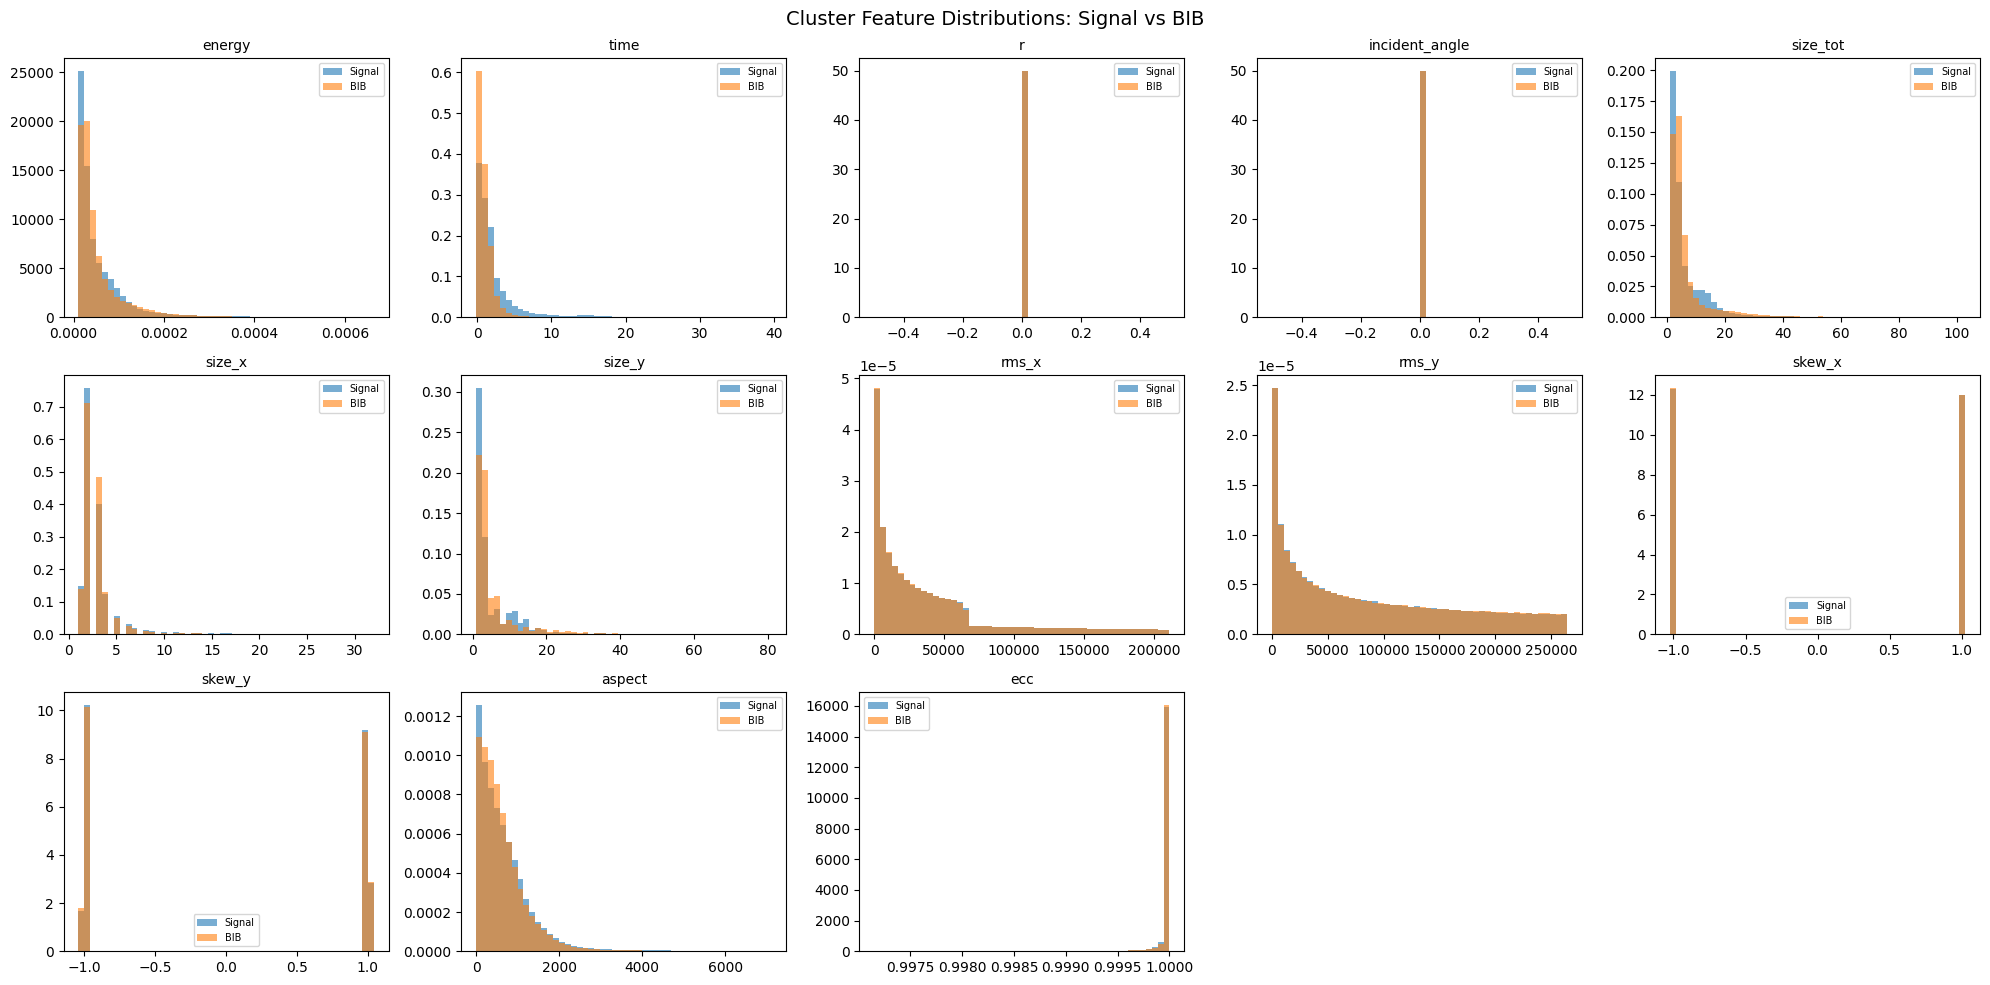

In [4]:
# Quick look at the cluster-level features
CLUSTER_FEATURES = data['feature_keys']
plot_feature_distributions(data, labels)

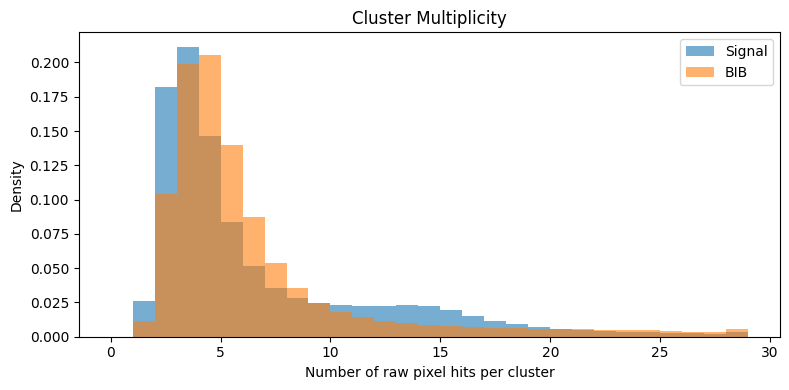

Raw hits per cluster — median: 4, mean: 10.3, max: 3410


In [5]:
# Distribution of raw hits per cluster
plot_hit_multiplicity(data, labels)

---
## 2. BDT Baseline — Easy Differentiation

Before reaching for deep learning, let's see how far we get with a **Boosted Decision Tree** trained on the cluster-level shape features. This is the same approach used in _PAPERNAME_.

In [6]:
# Build feature matrix for the BDT
X_bdt = np.column_stack([data['features'][f] for f in CLUSTER_FEATURES])
y_bdt = labels.astype(int)

# Replace NaN/Inf with 0 (can happen for clusters with 0 raw hits)
X_bdt = np.nan_to_num(X_bdt, nan=0.0, posinf=0.0, neginf=0.0)

# Use the same train/val/test splits as the Transformer
X_train, y_train = X_bdt[data['idx_train']], y_bdt[data['idx_train']]
X_val,   y_val   = X_bdt[data['idx_val']],   y_bdt[data['idx_val']]
X_test,  y_test  = X_bdt[data['idx_test']],  y_bdt[data['idx_test']]

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

Train: 2643669  Val: 377667  Test: 755335


In [7]:
N_ESTIMATORS = 200
EXTRA_TREES  = 5   # additional trees when warm-starting from a pretrained BDT

if PRETRAINED_BDT and os.path.exists(PRETRAINED_BDT):
    bdt = joblib.load(PRETRAINED_BDT)
    n_existing = bdt.n_estimators_
    bdt.warm_start = True
    bdt.n_estimators = n_existing + EXTRA_TREES
    print(f"Loaded pre-trained BDT from {PRETRAINED_BDT} ({n_existing} trees), adding {EXTRA_TREES} more...")
else:
    bdt = GradientBoostingClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_SEED,
        verbose=1,
    )

bdt.fit(X_train, y_train)

Loaded pre-trained BDT from bdt_weights.pkl (200 trees), adding 5 more...
      Iter       Train Loss      OOB Improve   Remaining Time 
       201           0.9103          -0.0010           45.32s
       202           0.9109           0.0029           34.18s
       203           0.9101          -0.0028           22.52s
       204           0.9100          -0.0004           11.32s
       205           0.9093          -0.0021            0.00s


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",205
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 


BDT AUC: 0.8596
Accuracy: 0.7759
  Signal eff = 0.500  ->  1 - BIB eff = 0.9273
  Signal eff = 0.800  ->  1 - BIB eff = 0.7446
  Signal eff = 0.900  ->  1 - BIB eff = 0.5934
  Signal eff = 0.950  ->  1 - BIB eff = 0.4792


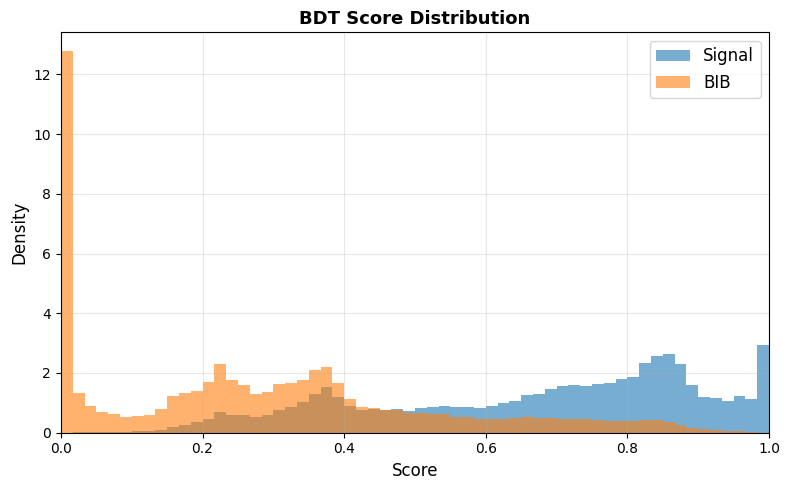

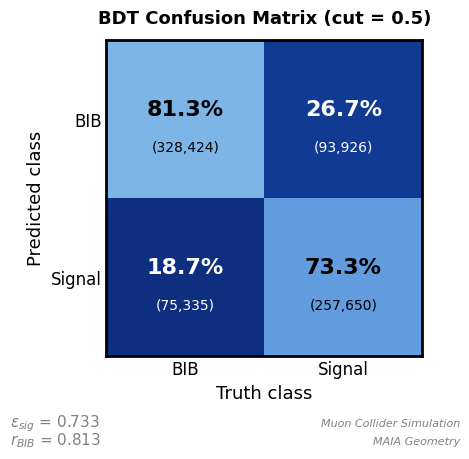

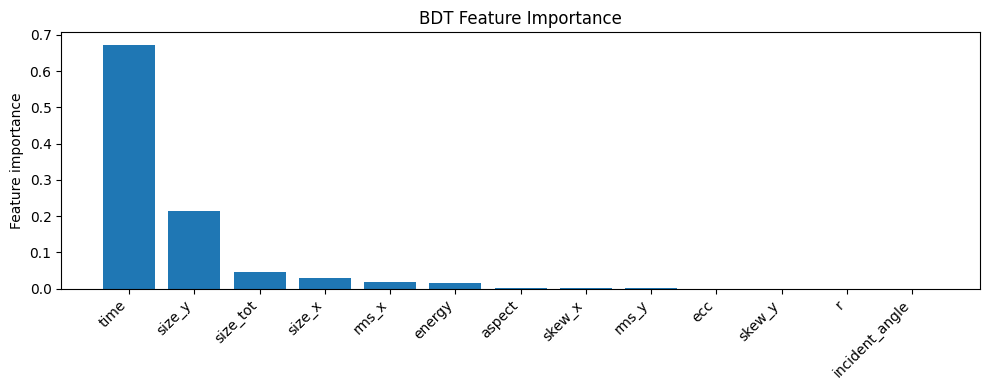

In [8]:
# Evaluate BDT
bdt_scores = bdt.predict_proba(X_test)[:, 1]
bdt_results = evaluate_classifier(y_test, bdt_scores, 'BDT')
plot_score_distributions(y_test, bdt_scores, title='BDT Score Distribution')
plot_confusion_matrix(y_test, bdt_scores, cut=0.5, title='BDT Confusion Matrix (cut = 0.5)')
plot_feature_importance(bdt, CLUSTER_FEATURES)

---
## 3. Transformer on Raw Pixel Hits

The BDT uses **pre-computed** shape features (RMS, skewness, etc.). But what if the network could learn directly from the **raw pixel hits**?

Each cluster is a variable-length set of pixel hits with features `(energy, time, x, y, z)`. 

Since you've already seen how Transformers work, let's jump straight in.

In [9]:
# Recall what our data structure looks like
print(f"Train: {len(train_loader.dataset)}  Val: {len(val_loader.dataset)}  Test: {len(test_loader.dataset)}")
print(f"Sequence length (max raw hits): {MAX_RAW_HITS}")
print(f"Input features per hit: 5  (energy, time, x, y, z)")

Train: 2643669  Val: 377667  Test: 755335
Sequence length (max raw hits): 9
Input features per hit: 5  (energy, time, x, y, z)


### The Model

We use a Transformer encoder that processes the set of raw pixel hits and aggregates them into a classification decision. The architecture mirrors the one from the Transformers tutorial:

- **Input projection** to hidden dimension
- **N Transformer blocks** (attention + feed-forward + skip connections + normalization)
- **Mean pooling** over the sequence (masked)
- **Classification head**

In [10]:
class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)

    def forward(self, x, mask):
        q = self.q(x) * mask
        k = self.k(x) * mask
        v = self.v(x) * mask
        attn = (q @ k.transpose(-2, -1)).softmax(dim=-1)
        return (attn @ v) * mask


class TransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = Attention(dim)
        self.proj1 = nn.Linear(dim, dim)
        self.proj2 = nn.Linear(dim, dim)
        self.activation = nn.GELU()
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, mask):
        x = x + self.att(self.norm1(x), mask)
        x = self.activation(self.proj1(x)) * mask
        x = x + self.proj2(self.norm2(x)) * mask
        return x


class PixelTransformer(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, num_layers=2, num_classes=2):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([TransformerBlock(hidden_dim) for _ in range(num_layers)])
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Mask: a hit is "real" if energy (feature 0) is nonzero
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()
        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)
        # Mean pool over non-padded hits
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.output_layer(x)

In [11]:
config = {
    'input_dim': 5,
    'hidden_dim': 64,
    'num_layers': 2,
    'num_classes': 2,
}

model = PixelTransformer(**config).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

PixelTransformer(
  (input_layer): Linear(in_features=5, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (att): Attention(
        (q): Linear(in_features=64, out_features=64, bias=True)
        (k): Linear(in_features=64, out_features=64, bias=True)
        (v): Linear(in_features=64, out_features=64, bias=True)
      )
      (proj1): Linear(in_features=64, out_features=64, bias=True)
      (proj2): Linear(in_features=64, out_features=64, bias=True)
      (activation): GELU(approximate='none')
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output_layer): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 42,626


In [12]:
# Optional: load pre-trained weights (set PRETRAINED_WEIGHTS in the config cell above)
if PRETRAINED_WEIGHTS and os.path.exists(PRETRAINED_WEIGHTS):
    checkpoint = torch.load(PRETRAINED_WEIGHTS, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict, strict=False)
    print(f"Loaded pre-trained weights from {PRETRAINED_WEIGHTS}")
else:
    print("Training from scratch (no pre-trained weights loaded)")

Loaded pre-trained weights from transformer_weights.pt


In [14]:
# Train the Transformer
pretrained = PRETRAINED_WEIGHTS and os.path.exists(PRETRAINED_WEIGHTS)
trainer = Trainer(
    train_dataset=train_loader,
    val_dataset=val_loader,
    model=model,
    lr=1e-4 if pretrained else 5e-4,
    optimizer=torch.optim.Adam,
    loss_fn=nn.CrossEntropyLoss,
    device=device,
)
trainer.train(num_epochs=5 if pretrained else 30,
              patience=3 if pretrained else 10)
model = trainer.model

Epoch 1: train loss=0.4861, val loss=0.4859
Epoch 2: train loss=0.4858, val loss=0.4853
Epoch 3: train loss=0.4858, val loss=0.4850
Epoch 4: train loss=0.4855, val loss=0.4856
Epoch 5: train loss=0.4856, val loss=0.4856
Training complete. Total time: 506.6s



Transformer AUC: 0.8342
Accuracy: 0.7451
  Signal eff = 0.500  ->  1 - BIB eff = 0.9042
  Signal eff = 0.800  ->  1 - BIB eff = 0.6830
  Signal eff = 0.900  ->  1 - BIB eff = 0.5494
  Signal eff = 0.950  ->  1 - BIB eff = 0.4486


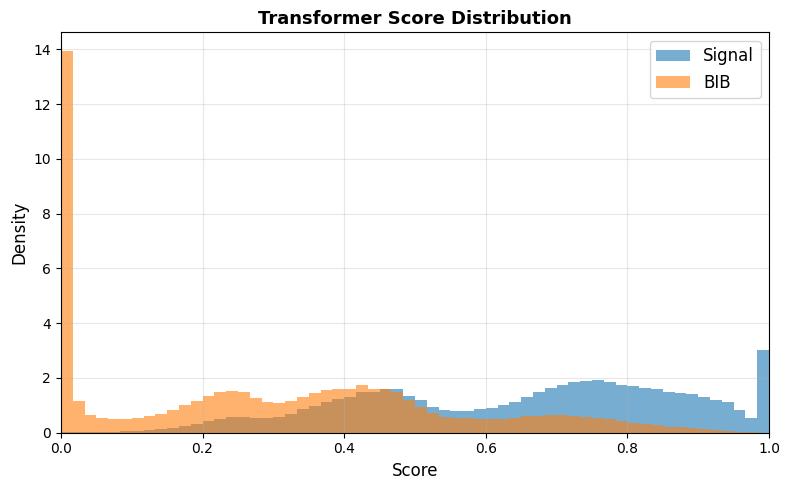

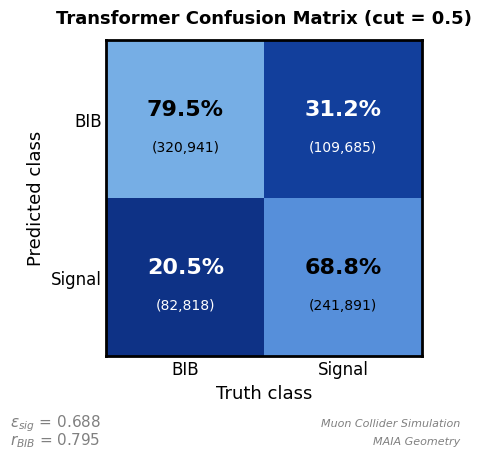

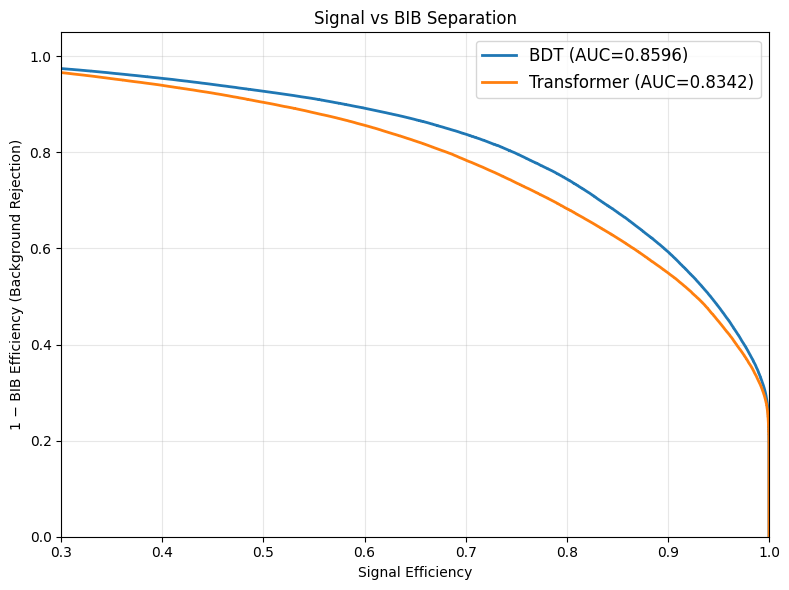

In [15]:
# Evaluate Transformer
tf_scores, labels_tf = predict_model(model, test_loader, device)
tf_results = evaluate_classifier(labels_tf, tf_scores, 'Transformer')
plot_score_distributions(labels_tf, tf_scores, title='Transformer Score Distribution')
plot_confusion_matrix(labels_tf, tf_scores, cut=0.5, title='Transformer Confusion Matrix (cut = 0.5)')

# Compare BDT vs Transformer
plot_roc_comparison({'BDT': bdt_results, 'Transformer': tf_results})

---
## 4. Your Turn: Experiment!

Try changing the model architecture and hyperparameters. Some ideas:

- **More or fewer layers**: how does depth affect performance?
- **Hidden dimension**: wider networks learn more complex patterns -- but at what cost?
- **Max raw hits**: what happens if you include more pixel hits per cluster?
- **Combine features**: can you concatenate cluster-level features with the Transformer output?
- **Learning rate & schedule**: try a cosine schedule or warm-up

Re-run the cells above after changing the config below.

In [16]:
# Modify these and re-run from the model definition cell

config = {
    'input_dim': 5,
    'hidden_dim': 64,   # try 32, 128
    'num_layers': 2,    # try 1, 3, 4
    'num_classes': 2,
}

MAX_RAW_HITS = 20      # try 10, 30, 50
# Remember to rebuild the datasets if you change MAX_RAW_HITS!

---
## 5. The On-Chip Challenge

In a real detector, the BIB filter must run at the **hardware trigger level** (on an FPGA or ASIC), with strict constraints on latency, power, and area. That means:

- **Fewer parameters** → smaller chip area
- **Fewer operations** → lower latency and power
- **Lower precision** → quantization from float32 to int8 or even binary

Your challenge: **make the smallest, most efficient model that still separates signal from BIB.**

We'll use a **Figure of Merit (FoM)** that rewards both performance and compactness:

$$ \text{FoM} = \frac{\text{AUC}}{\log_{10}(\text{Model Size in Bytes})} $$

A perfect model with AUC = 1.0 stored in 1 KB would achieve FoM = $1.0 / 3 \approx 0.33$. Can you beat that?

In [17]:
# Benchmark the Transformer
tf_bench = benchmark_model(model, test_loader, device=device)
print_benchmark(tf_bench, 'Transformer')


 Transformer Benchmark
  Parameters:          42,626
  Size (FP32):        170,504 bytes  (166.5 KB)
  Size (INT8):         42,626 bytes  (41.6 KB)
  BOPs (FP32):      2,650,112
  Latency:               1.17 ms / batch
  AUC:                 0.8342
  FoM (FP32):          0.1595
  FoM (INT8):          0.1802


In [20]:
# Benchmark the BDT for comparison
bdt_bench = benchmark_bdt(bdt, bdt_results['auc'])


 BDT Benchmark
  Trees:                  205
  Max depth:                4
  Serialized size:    520,934 bytes  (508.7 KB)
  AUC:                 0.8596
  FoM:                 0.1504


### Leaderboard

Run the cell below to see how your model stacks up. Try to **maximize the Figure of Merit** by finding the best balance between performance and size.


Rank  Model                          AUC  Size (KB)      FoM
------------------------------------------------------------
1     Transformer                 0.8342      166.5   0.1595
2     BDT (baseline)              0.8596      508.7   0.1504


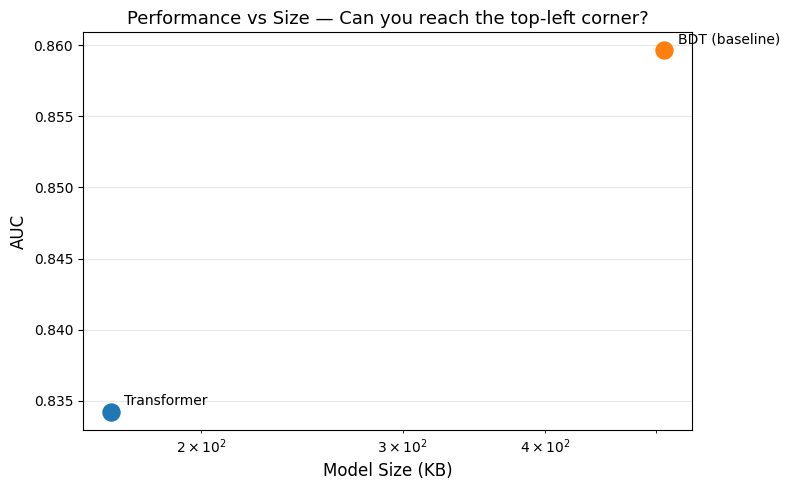

In [21]:
# Leaderboard
plot_leaderboard([
    ('BDT (baseline)',  bdt_bench['auc'], bdt_bench['size_bytes'],    bdt_bench['fom']),
    ('Transformer',     tf_bench['auc'],  tf_bench['size_fp32_bytes'], tf_bench['fom_fp32']),
])

### Tips for shrinking your model

- Reduce `hidden_dim` (e.g. 32 → 16 → 8)
- Use fewer layers (`num_layers` = 1)
- Reduce `MAX_RAW_HITS` to limit sequence length
- Try weight sharing across transformer blocks
- Replace the Transformer with a simpler architecture (DeepSets, 1D CNN)
- Knowledge distillation: train a tiny model to mimic the big one

When you have a model you're happy with, add it to the leaderboard:
```python
my_bench = benchmark_model(my_model, test_loader, device=device)
leaderboard.append(('My Model', my_bench['auc'], my_bench['size_fp32_bytes'], my_bench['fom_fp32']))
```

In [ ]:
# Save your best model
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'config': config,
#     'auc': tf_bench['auc'],
# }, 'best_pixel_transformer.pt')